# Design D4 (well D4 -- "H1" in `spectra_normalization.ipynb`'s layout), background-subtracted, vs EGFP/avGFP

One combined excitation/emission spectrum for well **D4**, this run's exp2 pair of scans
(`p3: Em560`, an excitation sweep with emission fixed at 560 nm, and `p4: Ex390`, an emission
sweep with excitation fixed at 390 nm) -- the same two plates
`./spectra_normalization.ipynb` uses for its Fig5/Fig6. D4's own excitation
curve peaks right at 390 nm and its emission curve peaks around 510 nm, which is why this pair (not
one of the other five exp2 scans) is the one that actually brackets this well's spectrum.

Both curves are **background-subtracted** by well **B4** (pUC, empty-vector control -- plain
*E. coli* with no FP expressed) from the same plate/scan before normalizing: `D4 minus B4`, raw
fluorescence, wavelength-for-wavelength. The subtracted curve is checked below to be positive at
every wavelength in both scans, so nothing needs clipping. EGFP and avGFP reference curves come
from FPbase (`../../fpbase-extractor/fpbase_output/fpbase_spectra.json`), already peak-normalized
to 1.0 by FPbase itself.

In [1]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000/650/490 px panel really is that.
get_ipython().run_line_magic('config', 'InlineBackend.print_figure_kwargs = {"bbox_inches": None}')

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import arcadia_pycolor as apc

FONTS = "../../dataset_pipeline/fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: shared font dir not found -- run dataset_pipeline/fetch_arcadia_fonts.py, "
          "figures will render in a substitute font in the meantime.")

PX = 1 / 72          # one style-guide pixel, in inches
FLOAT_W = 650        # single-column panel width, px
FLOAT_H = FLOAT_W * 2 / 3   # 3:2 width:height

DATA_CSV = Path("20260831_jeb_zz_FP_raw_well_data.csv")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

raw = pd.read_csv(DATA_CSV)

In [2]:
def get_spectrum(plate, well):
    """(wavelengths, values) for one well of a spectral plate, sorted by wavelength."""
    sel = raw[(raw.plate_name == plate) & (raw.well_position == well)].sort_values("wavelength")
    return sel.wavelength.to_numpy(), sel.value.to_numpy()


design_ex_wl, design_ex_val = get_spectrum("p3: Em560", "D4")
ecoli_ex_wl, ecoli_ex_val = get_spectrum("p3: Em560", "B4")
design_em_wl, design_em_val = get_spectrum("p4: Ex390", "D4")
ecoli_em_wl, ecoli_em_val = get_spectrum("p4: Ex390", "B4")

assert np.array_equal(design_ex_wl, ecoli_ex_wl), "design/E. coli excitation scans must share a wavelength grid to subtract"
assert np.array_equal(design_em_wl, ecoli_em_wl), "design/E. coli emission scans must share a wavelength grid to subtract"

design_ex_subtracted = design_ex_val - ecoli_ex_val
design_em_subtracted = design_em_val - ecoli_em_val
assert (design_ex_subtracted > 0).all(), "expected D4 to read higher than the empty-vector well at every excitation wavelength"
assert (design_em_subtracted > 0).all(), "expected D4 to read higher than the empty-vector well at every emission wavelength"

design_ex_norm = design_ex_subtracted / design_ex_subtracted.max()
design_em_norm = design_em_subtracted / design_em_subtracted.max()

print("excitation peak:", design_ex_wl[design_ex_subtracted.argmax()], "nm")
print("emission peak:", design_em_wl[design_em_subtracted.argmax()], "nm")

excitation peak: 390 nm
emission peak: 510 nm


In [3]:
egfp_b1_ex_wl, egfp_b1_ex_val = get_spectrum("p3: Em560", "B1")
egfp_b1_em_wl, egfp_b1_em_val = get_spectrum("p4: Ex390", "B1")

# Same treatment as D4 above: background-subtracted by the same plate's B4 (pUC) well, then
# normalized by its own peak -- so the measured EGFP positive control (well B1) is directly
# comparable to D4, not just to the FPbase reference curve.
egfp_b1_ex_subtracted = egfp_b1_ex_val - ecoli_ex_val
egfp_b1_em_subtracted = egfp_b1_em_val - ecoli_em_val
assert (egfp_b1_ex_subtracted > 0).all(), "expected B1 to read higher than the empty-vector well at every excitation wavelength"
assert (egfp_b1_em_subtracted > 0).all(), "expected B1 to read higher than the empty-vector well at every emission wavelength"

egfp_b1_ex_norm = egfp_b1_ex_subtracted / egfp_b1_ex_subtracted.max()
egfp_b1_em_norm = egfp_b1_em_subtracted / egfp_b1_em_subtracted.max()

print("EGFP (B1) excitation peak:", egfp_b1_ex_wl[egfp_b1_ex_subtracted.argmax()], "nm")
print("EGFP (B1) emission peak:", egfp_b1_em_wl[egfp_b1_em_subtracted.argmax()], "nm")

EGFP (B1) excitation peak: 490 nm
EGFP (B1) emission peak: 520 nm


In [4]:
def spectral_peak_wavelengths(wavelength, value, prominence=0.15):
    """Wavelengths of every locally prominent peak, global max first. A peak's prominence is its
    height above the higher of the two valleys you'd have to cross to reach a taller point (or the
    array edge) in each direction -- the same definition scipy.signal.find_peaks uses, reimplemented
    here to avoid adding scipy as a dependency for one small helper."""

    def _prominence(i):
        def walk_min(arr):
            m = arr[0]
            for v in arr[1:]:
                m = min(m, v)
                if v > arr[0]:
                    break
            return m
        return value[i] - max(walk_min(value[:i + 1][::-1]), walk_min(value[i:]))

    is_local_max = (value[1:-1] > value[:-2]) & (value[1:-1] > value[2:])
    candidates = np.where(is_local_max)[0] + 1
    peaks = [i for i in candidates if _prominence(i) >= prominence]
    main = int(value.argmax())
    if main not in peaks:
        peaks.append(main)
    peaks.sort(key=lambda i: -value[i])
    return [wavelength[i] for i in peaks]


for label, wl, val in [
    ("Design D4 excitation", design_ex_wl, design_ex_norm),
    ("Design D4 emission", design_em_wl, design_em_norm),
    ("EGFP (B1) excitation", egfp_b1_ex_wl, egfp_b1_ex_norm),
    ("EGFP (B1) emission", egfp_b1_em_wl, egfp_b1_em_norm),
]:
    peaks = spectral_peak_wavelengths(wl, val)
    peaks_str = " / ".join(f"{p:.0f}" for p in peaks) + " nm"
    print(f"{label}: {peaks_str}")

Design D4 excitation: 390 / 500 nm
Design D4 emission: 510 nm
EGFP (B1) excitation: 490 nm
EGFP (B1) emission: 520 nm


In [5]:
FPBASE_SPECTRA = json.load(open("../../fpbase-extractor/fpbase_output/fpbase_spectra.json"))


def fpbase_spectrum(protein_name, spectrum_type):
    """(wavelength, normalized_intensity) for one protein/spectrum-type pair, from FPbase's
    cached export -- already peak-normalized to 1.0 by FPbase itself."""
    protein = next(p for p in FPBASE_SPECTRA if p.get("name") == protein_name)
    spectrum = next(s for s in protein["spectra"] if s["spectrum_type"] == spectrum_type)
    data = np.array(spectrum["data"])
    return data[:, 0], data[:, 1]


egfp_ex_wl, egfp_ex_val = fpbase_spectrum("EGFP", "excitation")
egfp_em_wl, egfp_em_val = fpbase_spectrum("EGFP", "emission")
avgfp_ex_wl, avgfp_ex_val = fpbase_spectrum("avGFP", "excitation")
avgfp_em_wl, avgfp_em_val = fpbase_spectrum("avGFP", "emission")

## Design D4 vs EGFP (well B1) -- excitation/emission overlay

Convention: solid = excitation, dashed = emission,
one color per protein, curve labels placed directly on the lines instead of a separate legend.
Both curves here are this run's own experimentally measured spectra -- Design D4 and the EGFP
positive control (well B1), both read on the same two exp2 scans (`p3: Em560`, `p4: Ex390`) and
given the same background-subtraction-by-B4 and own-peak normalization treatment -- no FPbase
reference curves in this figure. EGFP is `apc.fern` (the same identity color the measured EGFP
curve uses in the stacked figure below); Design D4 is `apc.amber`, an orange distinct from EGFP's
green (a deliberate choice for this figure -- `spectra_normalization.ipynb` uses a light blue,
`apc.vital`, for this same well elsewhere in the project).

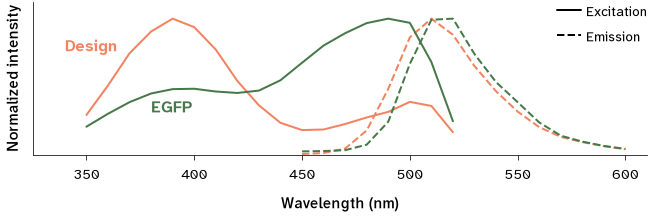

In [6]:
FIG1_DESIGN_COLOR = str(apc.amber)   # orange, distinct from EGFP's green (see markdown above)
FIG1_EGFP_COLOR = str(apc.fern)      # measured EGFP (B1) identity color, matches the stacked figure below

fig, ax = plt.subplots(figsize=(FLOAT_W * PX, 1/2 * FLOAT_H * PX), layout="constrained")

ax.plot(design_ex_wl, design_ex_norm, color=FIG1_DESIGN_COLOR, lw=2, ls="-")
ax.plot(design_em_wl, design_em_norm, color=FIG1_DESIGN_COLOR, lw=2, ls="--")
ax.plot(egfp_b1_ex_wl, egfp_b1_ex_norm, color=FIG1_EGFP_COLOR, lw=2, ls="-")
ax.plot(egfp_b1_em_wl, egfp_b1_em_norm, color=FIG1_EGFP_COLOR, lw=2, ls="--")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized intensity")
ax.set_xlim(325, 610)
ax.set_yticks([])
ax.set_ylim(0, 1.12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# apc.mpl.style_plot() auto-applies its own title-rule legend styling to any legend already on
# the axes -- called before the legend exists below, so the excitation/emission key stays a
# plain two-entry legend instead of picking up an (untitled) rule line above it.
apc.mpl.style_plot(ax, monospaced_axes="both")

# A normal matplotlib legend (two empty proxy artists, solid/dashed) stating the excitation/
# emission convention, so the per-FP labels below don't have to repeat it on every single curve.
ax.plot([], [], color="k", lw=2, ls="-", label="Excitation")
ax.plot([], [], color="k", lw=2, ls="--", label="Emission")
legend = ax.legend(loc="upper right", frameon=False, fontsize=14, handlelength=1.7)
# "constrained" layout otherwise treats the legend as a layout artist and shrinks the axes to
# make room for it outside the data area -- opt it out so it overlays the data area instead,
# actually sitting in the upper right corner rather than in a reserved margin beside it.
legend.set_in_layout(False)
apc.mpl.capitalize_legend_text(legend)
apc.mpl.justify_legend_text(legend)

# One label per FP (not per curve) -- color ties a label to both of that FP's curves at once.
LABEL_STYLE = dict(fontsize=16, ha="left", va="center", fontweight="bold")
ax.annotate("Design", xy=(340, 0.80), color=FIG1_DESIGN_COLOR, **LABEL_STYLE)
ax.annotate("EGFP", xy=(380, 0.35), color=FIG1_EGFP_COLOR, **LABEL_STYLE)

name = "Fig1_design-D4-H1_EGFP-overlay_Float"
for ext in ("svg", "png"):
    fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=300, bbox_inches=None)
plt.show()

## Design D4, EGFP, and avGFP as three stacked panels

Same excitation/emission curves as the overlay above, now as three vertically stacked panels
sharing one x-axis instead of one overlaid plot -- useful once peak positions are close enough
that overlaying gets crowded (here EGFP's excitation peak sits right in the trough between Design
D4's own two peaks). Convention: solid =
excitation, dashed = emission, each panel in its own identity color, panel label in place of a
separate legend. Total figure height is kept comparable to the overlay's single Float panel, not
three independent Float panels stacked.

The top (EGFP) panel additionally overlays this run's own **EGFP positive control (well B1)**,
read on the same two exp2 scans as D4 (`p3: Em560`, `p4: Ex390`) and given the same
background-subtraction-by-B4 and own-peak normalization treatment -- so it's directly comparable
to D4, not just to the FPbase reference curve. It keeps a darker shade of the same green family
(`apc.fern`) so it reads as "EGFP" alongside the lighter FPbase reference (`apc.lime`) while still
being visually distinct from it.

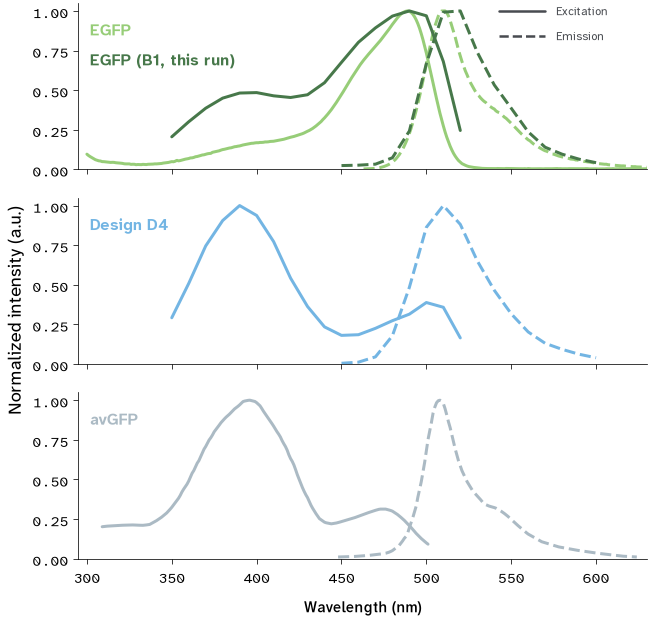

In [7]:
DESIGN_COLOR = str(apc.vital)   # same identity color as well D4's design in spectra_normalization.ipynb
EGFP_COLOR = str(apc.lime)      # EGFP's identity color elsewhere in this project (FPbase reference curve)
AVGFP_COLOR = str(apc.cloud)
EGFP_B1_COLOR = str(apc.fern)   # a darker shade of the same green family as EGFP_COLOR

STACK_ROWS = [
    ("EGFP", EGFP_COLOR, egfp_ex_wl, egfp_ex_val, egfp_em_wl, egfp_em_val),
    ("Design D4", DESIGN_COLOR, design_ex_wl, design_ex_norm, design_em_wl, design_em_norm),
    ("avGFP", AVGFP_COLOR, avgfp_ex_wl, avgfp_ex_val, avgfp_em_wl, avgfp_em_val),
]

STACK_H = 620   # total figure height, comparable to the overlay's single Float panel (FLOAT_H ~ 433 px)

stack_fig, axes = plt.subplots(3, 1, sharex=True, figsize=(FLOAT_W * PX, STACK_H * PX),
                                layout="constrained")
stack_fig.get_layout_engine().set(hspace=0.08)

for i, (ax, (label, color, ex_wl, ex_val, em_wl, em_val)) in enumerate(zip(axes, STACK_ROWS)):
    ax.plot(ex_wl, ex_val, color=color, lw=3, ls="-")
    ax.plot(em_wl, em_val, color=color, lw=3, ls="--")
    ax.set_xlim(295, 630)
    ax.set_ylim(0, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.annotate(label, xy=(0.02, 0.90), xycoords="axes fraction", ha="left", va="top",
                color=color, fontsize=16, fontweight="bold")
    apc.mpl.style_plot(ax, monospaced_axes="both")
    if i < len(axes) - 1:
        ax.tick_params(labelbottom=False)

# Overlay this run's own EGFP positive control (well B1, same exp2 scans as D4) onto the EGFP
# panel, so the FPbase reference and the actual measured EGFP well sit side by side.
egfp_panel = axes[0]
egfp_panel.plot(egfp_b1_ex_wl, egfp_b1_ex_norm, color=EGFP_B1_COLOR, lw=3, ls="-")
egfp_panel.plot(egfp_b1_em_wl, egfp_b1_em_norm, color=EGFP_B1_COLOR, lw=3, ls="--")
egfp_panel.annotate("EGFP (B1, this run)", xy=(0.02, 0.72), xycoords="axes fraction",
                     ha="left", va="top", color=EGFP_B1_COLOR, fontsize=16, fontweight="bold")

axes[-1].set_xlabel("Wavelength (nm)")
stack_fig.supylabel("Normalized intensity (a.u.)")

KEY_STYLE = dict(color=str(apc.charcoal), fontsize=11.5, va="center", ha="left")
axes[0].plot([0.74, 0.82], [0.95, 0.95], transform=axes[0].transAxes, color=str(apc.charcoal), lw=2.5, ls="-")
axes[0].text(0.84, 0.95, "Excitation", transform=axes[0].transAxes, **KEY_STYLE)
axes[0].plot([0.74, 0.82], [0.80, 0.80], transform=axes[0].transAxes, color=str(apc.charcoal), lw=2.5, ls="--")
axes[0].text(0.84, 0.80, "Emission", transform=axes[0].transAxes, **KEY_STYLE)

name = "Fig2_design-D4-H1_EGFP-Design-avGFP-stacked_Float"
for ext in ("pdf", "png"):
    stack_fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=300, bbox_inches=None)
plt.show()

## Design D4 vs EGFP (well B1), with mOrange's target peaks marked

Same figure as the overlay above, with two vertical reference lines added at mOrange's own
excitation (548 nm) and emission (562 nm) peaks -- from FPbase's cached mOrange spectrum (the
same `fpbase_spectrum` helper used for EGFP/avGFP above), not from this run's own mOrange well
(B3): B3 sits on the same two exp2 scans as D4, but `p3: Em560`'s excitation sweep only covers
350-520 nm (548 nm is out of range) and `p4: Ex390`'s fixed 390 nm excitation is far from
mOrange's own ~548 nm excitation optimum, so B3's own background-subtracted signal on these two
scans is unreliable (partly negative) rather than a usable target. The two lines use the same
solid=excitation/dashed=emission convention as the curves, in mOrange's own identity color
(`apc.tangerine`) elsewhere in this project, so the existing key still explains them without a
separate legend entry.

mOrange target excitation peak: 548.0 nm
mOrange target emission peak: 562.0 nm


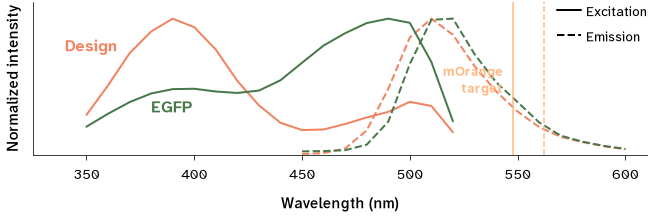

In [8]:
morange_ex_wl, morange_ex_val = fpbase_spectrum("mOrange", "excitation")
morange_em_wl, morange_em_val = fpbase_spectrum("mOrange", "emission")
morange_ex_peak = morange_ex_wl[morange_ex_val.argmax()]
morange_em_peak = morange_em_wl[morange_em_val.argmax()]
print("mOrange target excitation peak:", morange_ex_peak, "nm")
print("mOrange target emission peak:", morange_em_peak, "nm")

MORANGE_COLOR = str(apc.tangerine)   # mOrange's identity color elsewhere in this project

fig, ax = plt.subplots(figsize=(FLOAT_W * PX, 1/2 * FLOAT_H * PX), layout="constrained")

ax.plot(design_ex_wl, design_ex_norm, color=FIG1_DESIGN_COLOR, lw=2, ls="-")
ax.plot(design_em_wl, design_em_norm, color=FIG1_DESIGN_COLOR, lw=2, ls="--")
ax.plot(egfp_b1_ex_wl, egfp_b1_ex_norm, color=FIG1_EGFP_COLOR, lw=2, ls="-")
ax.plot(egfp_b1_em_wl, egfp_b1_em_norm, color=FIG1_EGFP_COLOR, lw=2, ls="--")

# mOrange's target peaks, as two thin vertical reference lines -- same solid/emission convention
# as the curves above, so the existing Excitation/Emission key also explains these.
ax.axvline(morange_ex_peak, color=MORANGE_COLOR, lw=1.5, ls="-")
ax.axvline(morange_em_peak, color=MORANGE_COLOR, lw=1.5, ls="--")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized intensity")
ax.set_xlim(325, 610)
ax.set_yticks([])
ax.set_ylim(0, 1.12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# apc.mpl.style_plot() auto-applies its own title-rule legend styling to any legend already on
# the axes -- called before the legend exists below, so the excitation/emission key stays a
# plain two-entry legend instead of picking up an (untitled) rule line above it.
apc.mpl.style_plot(ax, monospaced_axes="both")

# A normal matplotlib legend (two empty proxy artists, solid/dashed) stating the excitation/
# emission convention, so the per-FP labels below don't have to repeat it on every single curve.
ax.plot([], [], color="k", lw=2, ls="-", label="Excitation")
ax.plot([], [], color="k", lw=2, ls="--", label="Emission")
legend = ax.legend(loc="upper right", frameon=False, fontsize=14, handlelength=1.7)
# "constrained" layout otherwise treats the legend as a layout artist and shrinks the axes to
# make room for it outside the data area -- opt it out so it overlays the data area instead,
# actually sitting in the upper right corner rather than in a reserved margin beside it.
legend.set_in_layout(False)
apc.mpl.capitalize_legend_text(legend)
apc.mpl.justify_legend_text(legend)

# One label per FP (not per curve) -- color ties a label to both of that FP's curves at once.
LABEL_STYLE = dict(fontsize=16, ha="left", va="center", fontweight="bold")
ax.annotate("Design", xy=(340, 0.80), color=FIG1_DESIGN_COLOR, **LABEL_STYLE)
ax.annotate("EGFP", xy=(380, 0.35), color=FIG1_EGFP_COLOR, **LABEL_STYLE)
ax.annotate("mOrange\ntarget", xy=(morange_ex_peak - 5, 0.55), color=MORANGE_COLOR,
            fontsize=13, ha="right", va="center", fontweight="bold")

name = "Fig3_design-D4-H1_EGFP-overlay_mOrange-target_Float"
for ext in ("svg", "png"):
    fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=300, bbox_inches=None)
plt.show()